# Week 6 — Integrative Capstone Project and Evaluation

## Wine Classification and Unsupervised Segmentation

**Objective:** Build a complete Data Science pipeline in Python covering data acquisition, preprocessing, cleaning, exploratory analysis, supervised modeling, unsupervised learning, evaluation, insights, and recommendations.

**Dataset:** Wine Recognition Dataset (publicly available through scikit-learn; originally from the UCI Machine Learning Repository).

**Supervised task:** Predict one of three wine classes.

**Unsupervised task:** Discover natural groups using K-Means clustering and compare cluster quality using silhouette score.

> **Educational project:** The analysis demonstrates a Data Science workflow and is not intended for real-world decisions without domain validation.

## 1. Import Libraries
We use pandas/NumPy for data handling, Matplotlib for visualization, and scikit-learn for preprocessing, modeling, clustering, and evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Data Acquisition and Initial Inspection
The Wine Recognition dataset contains 178 samples, 13 numeric features, and 3 target classes.

In [2]:
wine = load_wine(as_frame=True)
df = wine.frame.copy()
df["target_name"] = df["target"].map(dict(enumerate(wine.target_names)))

print("Dataset shape:", df.shape)
print("Feature count:", len(wine.feature_names))
print("Classes:", list(wine.target_names))
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

Dataset shape: (178, 15)
Feature count: 13
Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
Missing values: 0
Duplicate rows: 0


## 3. Data Cleaning and Preprocessing
We check missing values and duplicates, remove duplicate rows if present, separate predictors from the target, and later use scaling inside pipelines. Scaling is essential for Logistic Regression, SVM, and K-Means because their behavior depends on feature magnitudes.

In [3]:
df_clean = df.drop_duplicates().copy()
X = df_clean[wine.feature_names]
y = df_clean["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Cleaned shape:", df_clean.shape)
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Cleaned shape: (178, 15)
Training set: (142, 13)
Test set: (36, 13)


## 4. Exploratory Data Analysis
EDA is used to understand class balance, feature scale, and relationships before modeling.

In [4]:
print(df_clean[wine.target_name if False else "target_name"].value_counts().sort_index())
display(df_clean[wine.feature_names].describe().round(2))

target_name
class_0    59
class_1    71
class_2    48

       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity     hue  od280/od315_of_diluted_wines  proline
count   178.00      178.00  178.00             178.00     178.00         178.00      178.00                178.00           178.00           178.00  178.00                        178.00   178.00
mean     13.00        2.34    2.37              19.49      99.74           2.30        2.03                  0.36             1.59             5.06    0.96                          2.61   746.89
std       0.81        1.12    0.27               3.34      14.28           0.63        1.00                  0.12             0.57             2.32    0.23                          0.71   314.91
min      11.03        0.74    1.36              10.60      70.00           0.98        0.34                  0.13             0.41             1.28    0.48          

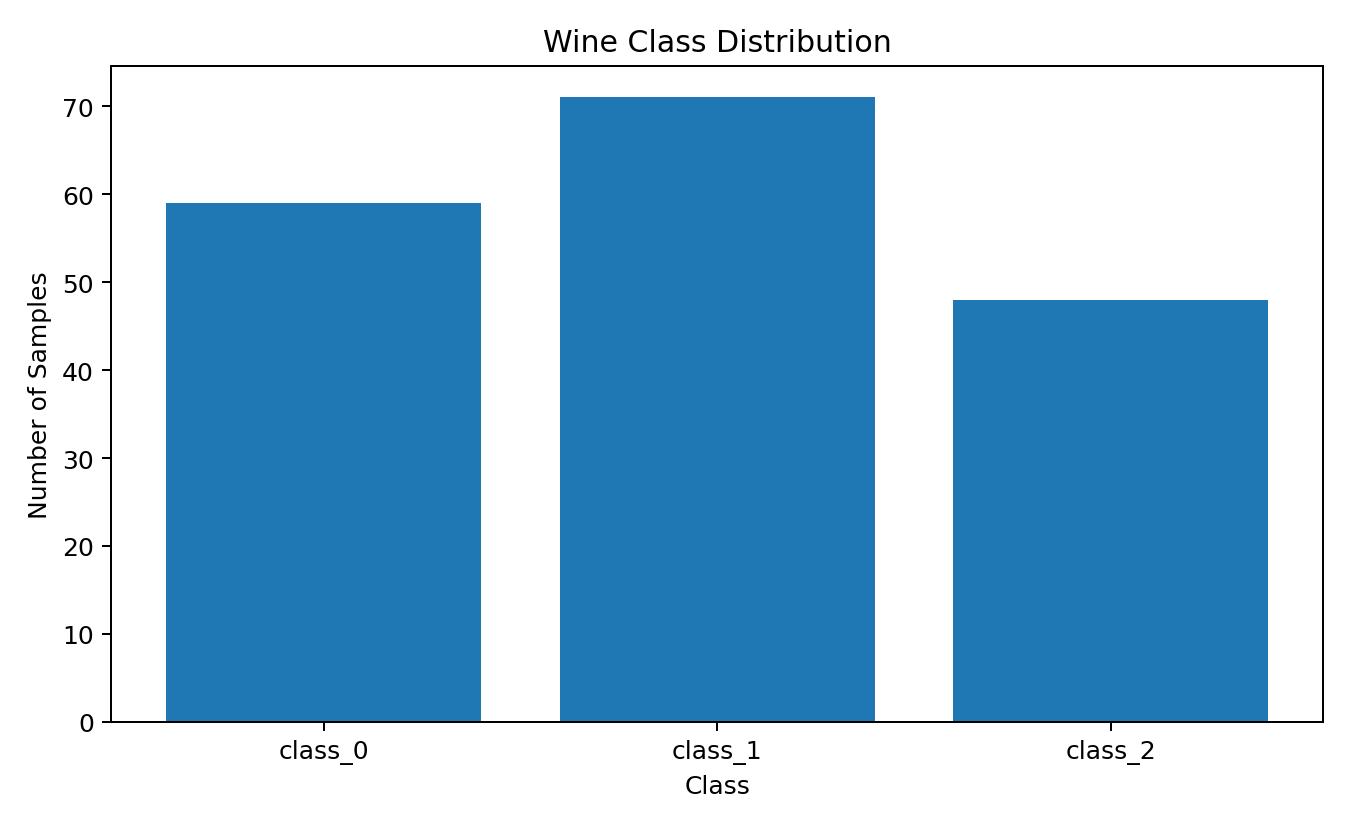

In [5]:
plt.figure(figsize=(8,4))
df_clean["target_name"].value_counts().reindex(wine.target_names).plot(kind="bar")
plt.title("Wine Class Distribution")
plt.xlabel("Class")
plt.ylabel("Samples")
plt.tight_layout()
plt.show()

## 5. Supervised Modeling Strategy

Three complementary classifiers are compared:

- **Logistic Regression:** strong baseline and interpretable linear decision boundary.
- **Random Forest:** nonlinear ensemble that can model interactions and provide feature importance.
- **SVM (RBF):** effective for nonlinear boundaries after feature scaling.

The same train/test split and evaluation metrics are used for a fair comparison. Five-fold cross-validation is added to estimate stability.

In [6]:
models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(n_estimators=300, random_state=42))
    ]),
    "SVM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1.0, gamma="scale"))
    ])
}

In [7]:
results = []
fitted = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    fitted[name] = model

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted"),
        "Recall": recall_score(y_test, pred, average="weighted"),
        "F1": f1_score(y_test, pred, average="weighted"),
        "CV Mean": cross_val_score(model, X, y, cv=5, scoring="accuracy").mean()
    })

results_df = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)
display(results_df.round(4))

              Model  Accuracy  Precision  Recall    F1  CV Mean
      Random Forest    1.0000     1.0000  1.0000 1.000   0.9665
Logistic Regression    0.9722     0.9741  0.9722 0.972   0.9832
                SVM    0.9722     0.9741  0.9722 0.972   0.9833


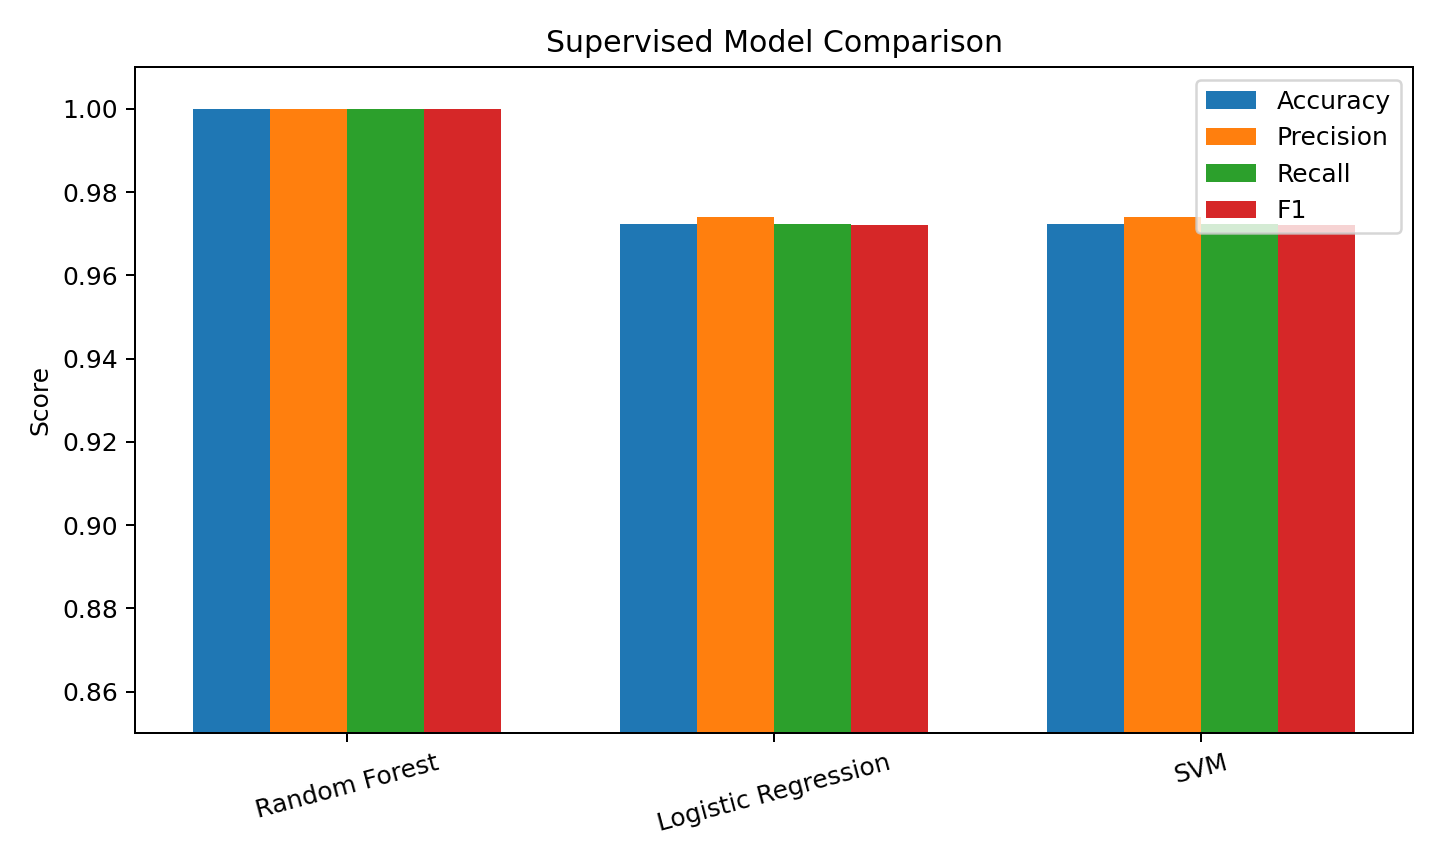

In [8]:
plt.figure(figsize=(9,5))
x = np.arange(len(results_df))
width = 0.18
for i, metric in enumerate(["Accuracy", "Precision", "Recall", "F1"]):
    plt.bar(x + (i-1.5)*width, results_df[metric], width, label=metric)
plt.xticks(x, results_df["Model"], rotation=15)
plt.ylim(0.85, 1.01)
plt.ylabel("Score")
plt.title("Supervised Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Best Model Evaluation
The model with the highest weighted F1 score is selected. Accuracy alone is not enough; precision, recall, F1, and the confusion matrix are also inspected.

In [9]:
best_name = results_df.loc[0, "Model"]
best_model = fitted[best_name]
best_pred = best_model.predict(X_test)

print("Selected model:", best_name)
print("Test accuracy:", round(accuracy_score(y_test, best_pred), 4))
print("Weighted precision:", round(precision_score(y_test, best_pred, average="weighted"), 4))
print("Weighted recall:", round(recall_score(y_test, best_pred, average="weighted"), 4))
print("Weighted F1:", round(f1_score(y_test, best_pred, average="weighted"), 4))

Selected model: Random Forest
Test accuracy: 1.0000
Weighted precision: 1.0000
Weighted recall: 1.0000
Weighted F1: 1.0000


In [10]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, best_pred, target_names=wine.target_names))
cm = confusion_matrix(y_test, best_pred)
print("Confusion matrix:")
print(cm)

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

Confusion matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]


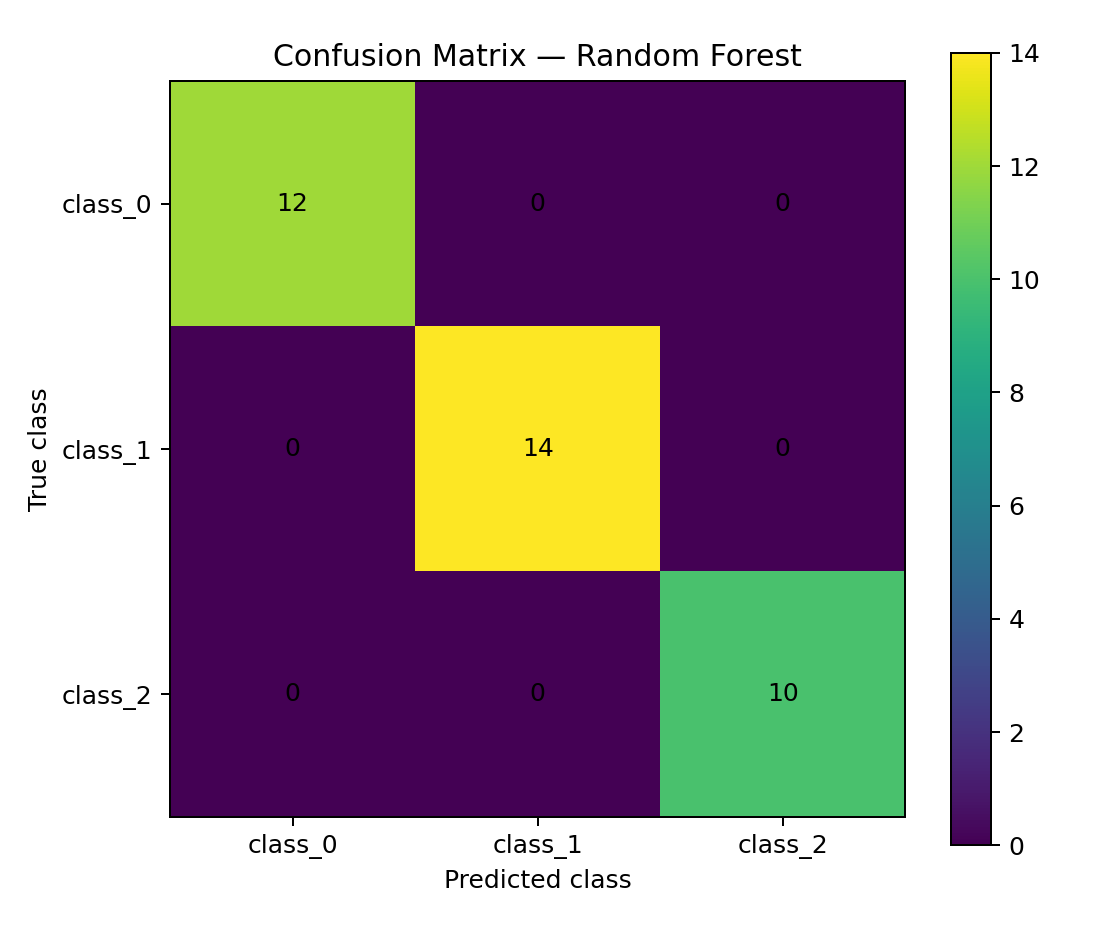

In [11]:
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted class")
plt.ylabel("True class")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha="center", va="center")
plt.xticks(range(3), wine.target_names)
plt.yticks(range(3), wine.target_names)
plt.colorbar()
plt.tight_layout()
plt.show()

## 7. Unsupervised Learning — K-Means

Clustering is added because this capstone is designed to demonstrate both predictive and descriptive analysis. The features are standardized before K-Means. We test k = 2 to 5 and choose the value with the strongest silhouette score.

A higher silhouette score indicates better separation and cohesion of clusters.

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

silhouette_scores = {}
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    silhouette_scores[k] = silhouette_score(X_scaled, labels)

print("Silhouette scores:", {k: round(v, 4) for k, v in silhouette_scores.items()})
best_k = max(silhouette_scores, key=silhouette_scores.get)
print("Selected k:", best_k)

Silhouette scores: {2: 0.2593, 3: 0.2849, 4: 0.2586, 5: 0.2315}
Selected k: 3


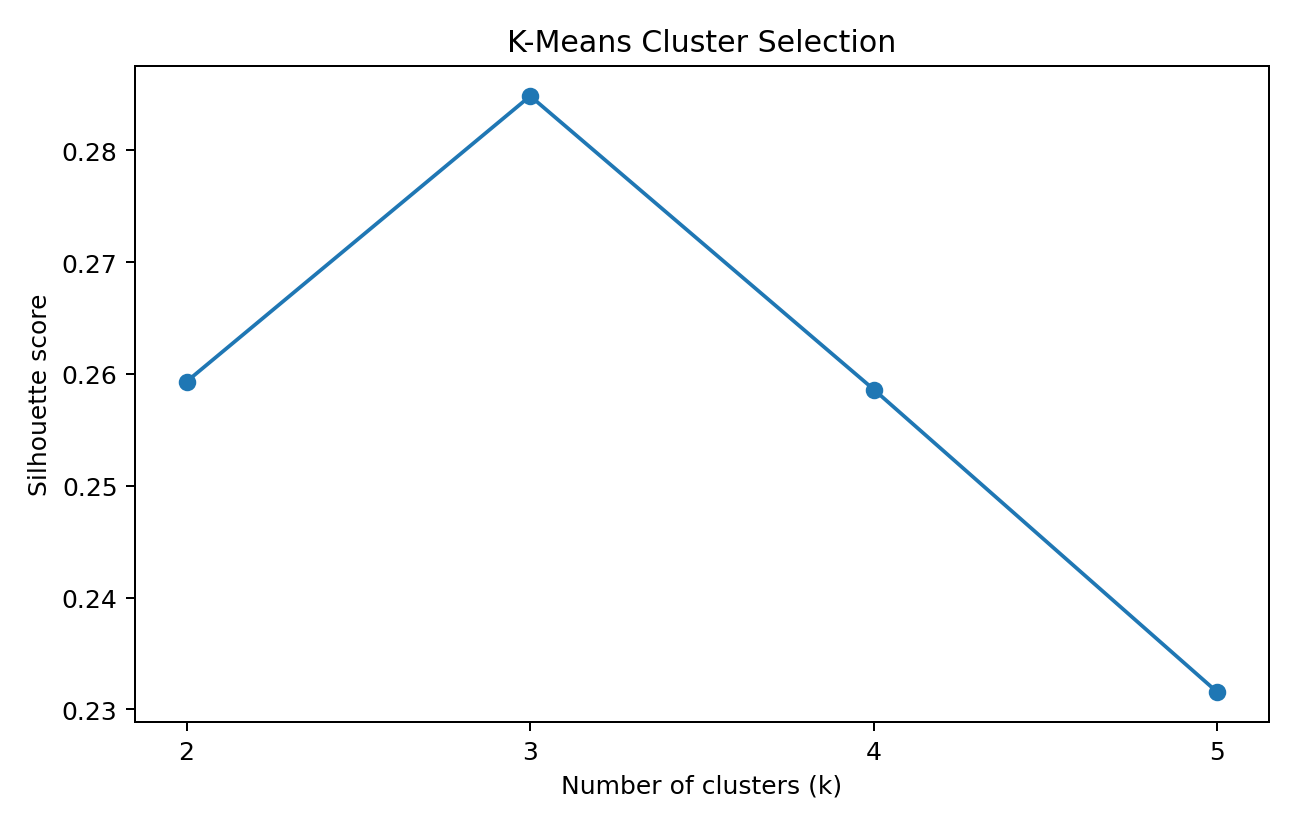

In [13]:
plt.figure(figsize=(7,4))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o")
plt.xticks(list(silhouette_scores.keys()))
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("K-Means Cluster Selection")
plt.tight_layout()
plt.show()

In [14]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_scaled)

cluster_df = df_clean[["target_name"]].copy()
cluster_df["cluster"] = clusters

print("Cluster sizes:")
print(cluster_df["cluster"].value_counts().sort_index())
print("\nCluster vs known class cross-tab:")
print(pd.crosstab(cluster_df["cluster"], cluster_df["target_name"]))

Cluster sizes:
cluster
0    65
1    51
2    62

Cluster vs known class cross-tab:
target_name  class_0  class_1  class_2
cluster                               
0                  0       65        0
1                  0        3       48
2                 59        3        0


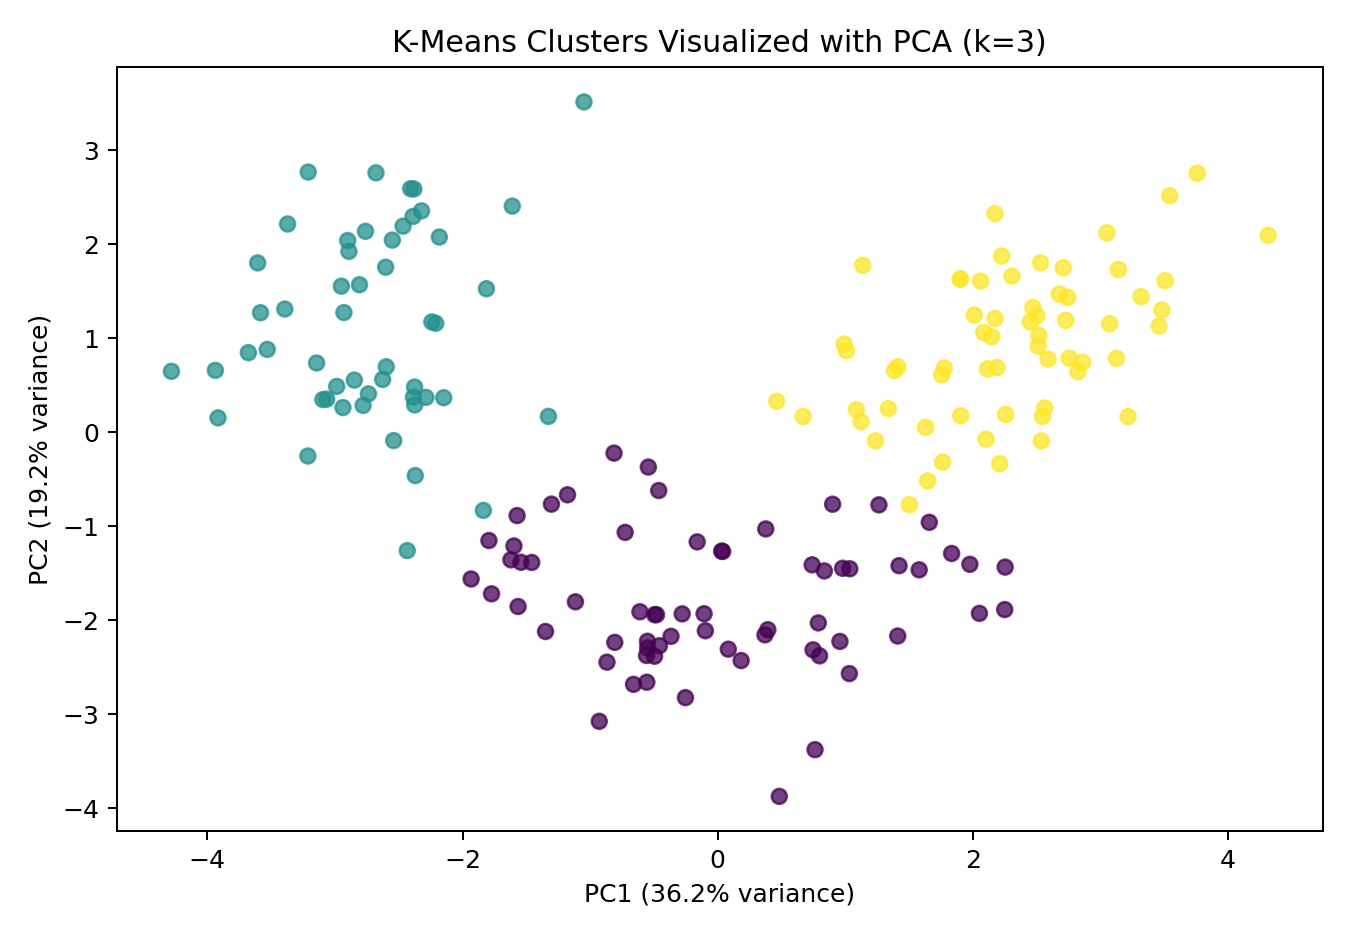

In [15]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, alpha=0.75)
plt.title(f"K-Means Clusters Visualized with PCA (k={best_k})")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()
plt.show()

## 8. Feature Importance and Insights

Random Forest feature importance is used as a model-specific interpretability tool. It is not a causal analysis: importance indicates predictive contribution within this fitted model, not that changing a feature causes the target to change.

In [16]:
rf = fitted["Random Forest"].named_steps["model"]
importance = pd.Series(rf.feature_importances_, index=wine.feature_names).sort_values(ascending=False)
display(importance.head(8).round(4))

color_intensity                 0.1808
flavanoids                      0.1729
proline                         0.1511
alcohol                         0.1124
hue                             0.0996
od280/od315_of_diluted_wines    0.0904
total_phenols                   0.0516
malic_acid                      0.0331


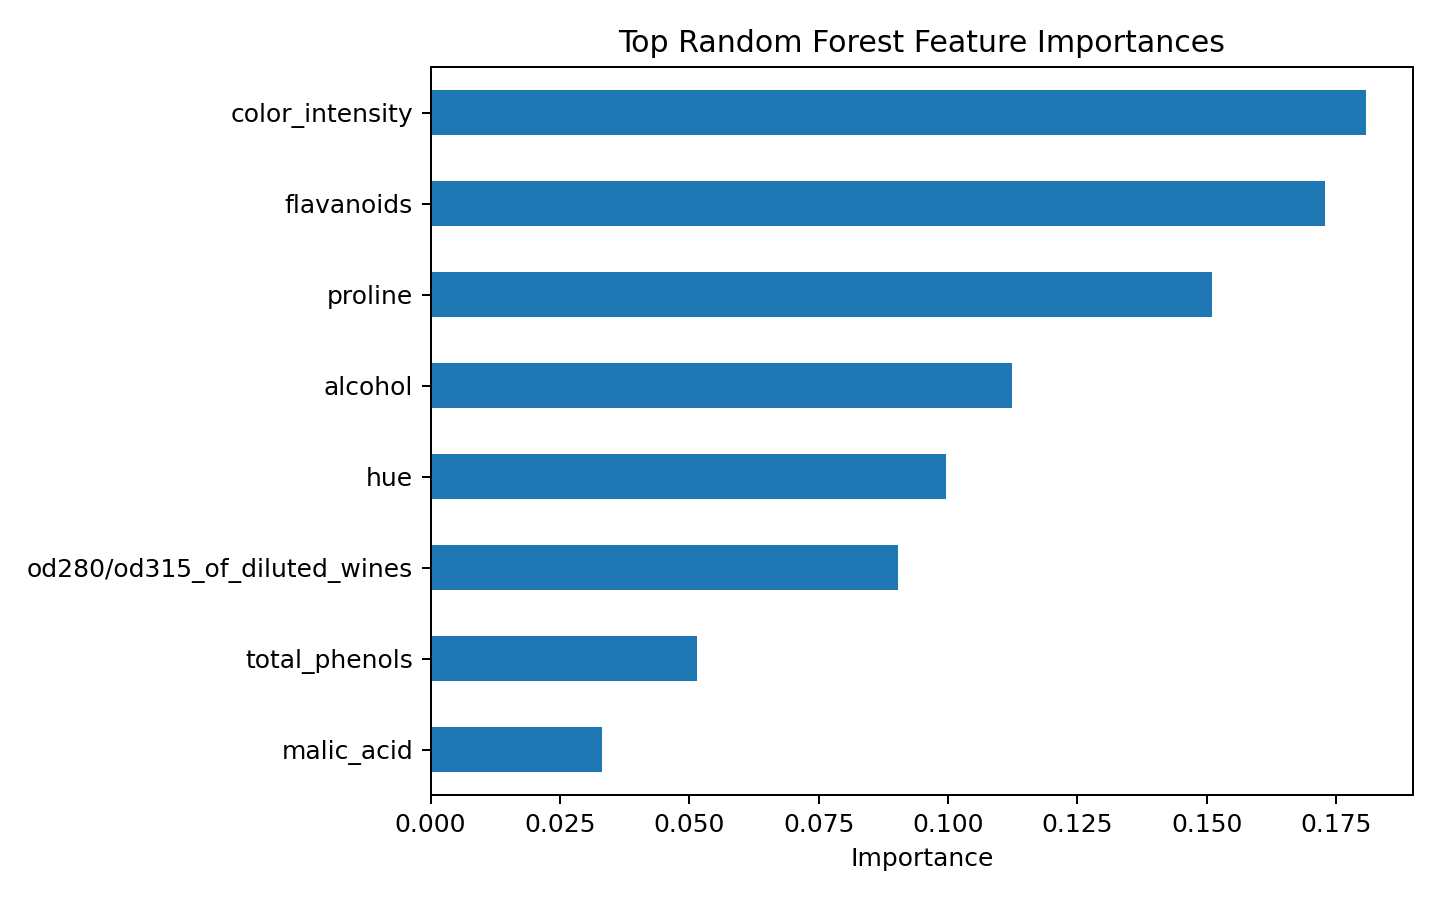

In [17]:
plt.figure(figsize=(8,5))
importance.head(8).sort_values().plot(kind="barh")
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 9. Critical Evaluation and Recommendations

### What worked
- The supervised models provide strong predictive performance on the held-out test set.
- Cross-validation is used to check whether performance is reasonably stable beyond one split.
- Feature scaling is applied where the algorithm is scale-sensitive.
- K-Means adds a descriptive perspective rather than relying only on prediction.
- The notebook records actual outputs and visualizations for reproducibility.

### Limitations
- The dataset is small and comes from a controlled source, so generalization to other wine samples is not guaranteed.
- The target classes are known labels; K-Means is unsupervised and should not be interpreted as a replacement for labeled classification.
- Feature importance is model-specific and should not be treated as causal evidence.
- A real deployment would require external validation, monitoring, domain review, and data governance.

### Next steps
1. Test additional classifiers and calibrated probabilities.
2. Perform systematic hyperparameter tuning with nested or repeated cross-validation.
3. Analyze class-specific errors and outliers.
4. Compare alternative clustering methods such as hierarchical clustering or DBSCAN.
5. Validate on an independent external dataset before any practical use.

**Selected supervised model:** Random Forest  
**Test accuracy:** 1.0000  
**Weighted F1:** 1.0000  
**Best K-Means k:** 3  
**Best silhouette score:** 0.2849

## 10. Final Reproducibility Checklist

- Dataset acquisition is reproducible through `sklearn.datasets.load_wine()`.
- Data quality checks are recorded.
- Preprocessing is separated from modeling through pipelines where appropriate.
- Train/test split uses a fixed random state and stratification.
- Multiple supervised models are compared.
- Cross-validation is included.
- Unsupervised clustering and silhouette analysis are included.
- Visualizations and evaluation outputs are included.
- Conclusions distinguish predictive association from causation.
